In [23]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [24]:
df = pd.read_csv("sensor_data_merged.csv")
df.head(5)

,Time,Value,State,Location,San_Jacinto_rain_5min,Caney_Creek_rain_5min,Time_hourly,temperature_c_hourly,humidity_percent_hourly,precipitation_mm_hourly,...,wind_direction_deg_hourly,wind_speed_kmh_hourly,wind_gust_kmh_hourly,pressure_hpa_hourly,sunshine_min_hourly,cloud_cover_percent_hourly,weather_code_hourly,forecasted_precipitation_hourly,Month,Season
0,2025-04-15 23:19:46.825,-.10 In.,Underrange,84_southwood_oaks,0.0,0.0,2025-04-15 23:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4,Spring
1,2025-04-16 01:11:55.352,-.10 In.,Underrange,84_southwood_oaks,0.0,0.0,2025-04-16 01:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4,Spring
2,2025-04-18 13:41:08.015,.01 In.,High High,84_bitter root,0.0,0.0,2025-04-18 14:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4,Spring
3,2025-04-18 13:41:38.699,.28 In.,High High,84_bitter root,0.0,0.0,2025-04-18 14:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4,Spring
4,2025-04-18 14:01:43.800,.18 In.,High,84_US_59,0.0,0.0,2025-04-18 14:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4,Spring


In [25]:
df["Location"].value_counts()

Location
84_bitter root       30745
84_avalon            29127
84_US_59             27150
84_southwood_oaks    25932
Southwood Laverne    25848
Name: count, dtype: int64

In [35]:
df.columns

Index(['Time', 'Value', 'State', 'Location', 'San_Jacinto_rain_5min',
       'Caney_Creek_rain_5min', 'Time_hourly', 'temperature_c_hourly',
       'humidity_percent_hourly', 'precipitation_mm_hourly',
       'snow_depth_cm_hourly', 'wind_direction_deg_hourly',
       'wind_speed_kmh_hourly', 'wind_gust_kmh_hourly', 'pressure_hpa_hourly',
       'sunshine_min_hourly', 'cloud_cover_percent_hourly',
       'weather_code_hourly', 'forecasted_precipitation_hourly', 'Month',
       'Season', 'Value_float', 'Water_Level_Change'],
      dtype='object')

In [31]:
df = df[df['Location'] == '84_avalon']

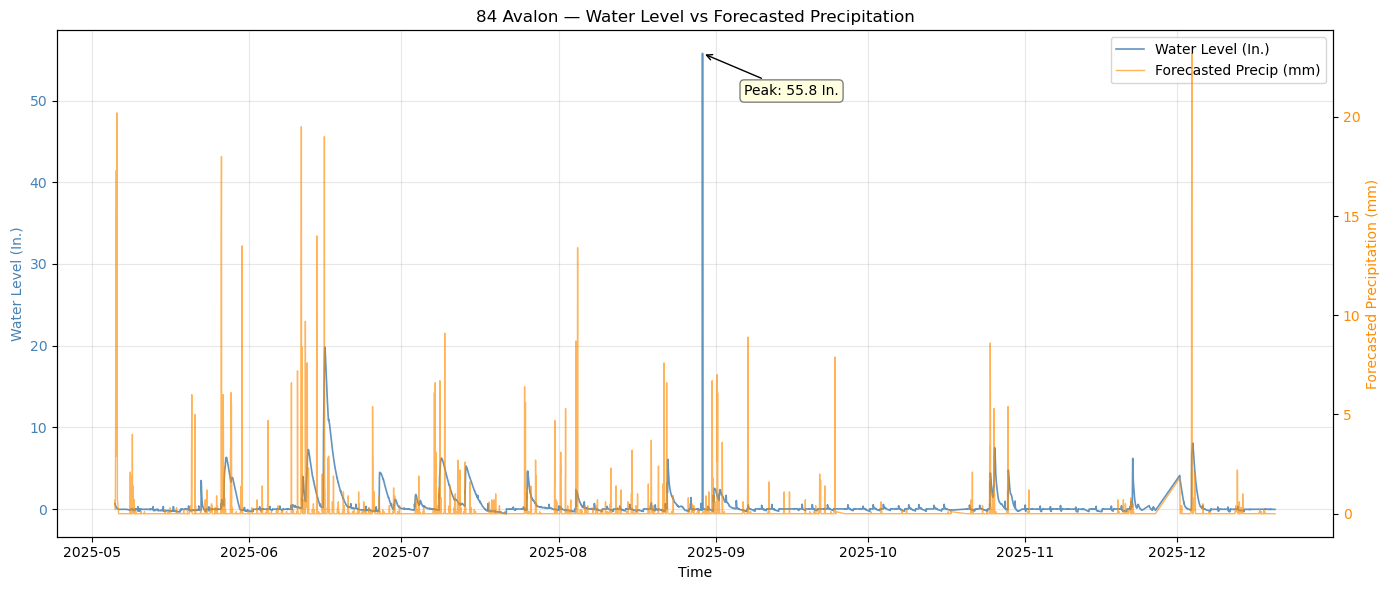

In [33]:
# Convert 'Time' to datetime and clean Value column
df['Time'] = pd.to_datetime(df['Time'])
df['Value_float'] = df['Value'].str.replace(' In.', '', regex=False).astype(float)
df = df.sort_values('Time').reset_index(drop=True)

# Figure with dual y-axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Water level (left axis)
ax1.plot(df['Time'], df['Value_float'], color='steelblue', linewidth=1.2, alpha=0.85, label='Water Level (In.)')
ax1.set_ylabel('Water Level (In.)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Forecasted precipitation (right axis)
ax2 = ax1.twinx()
ax2.plot(df['Time'], df['forecasted_precipitation_hourly'], color='darkorange', linewidth=1.0, alpha=0.65, label='Forecasted Precip (mm)')
ax2.set_ylabel('Forecasted Precipitation (mm)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Annotate peak water level
peak_idx = df['Value_float'].idxmax()
ax1.annotate(
    f"Peak: {df.loc[peak_idx, 'Value_float']:.1f} In.",
    xy=(df.loc[peak_idx, 'Time'], df.loc[peak_idx, 'Value_float']),
    xytext=(30, -30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)

# Labels, legend, formatting
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_xlabel('Time')
ax1.set_title('84 Avalon — Water Level vs Forecasted Precipitation')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

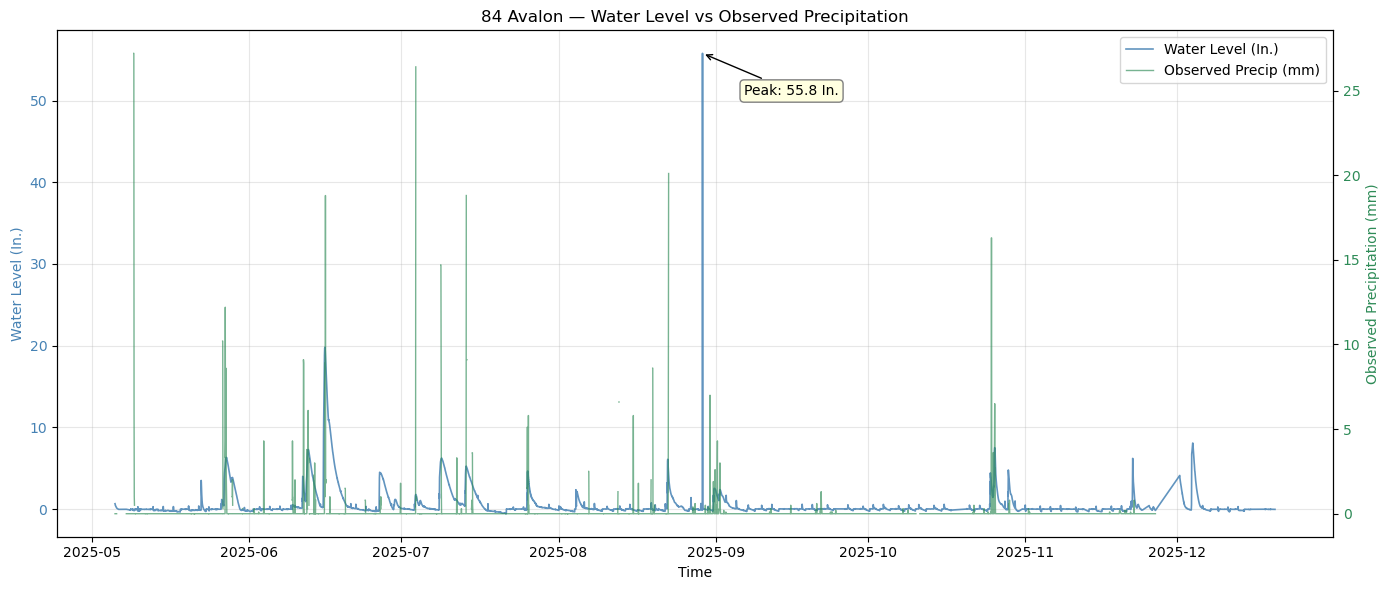

In [36]:
# Convert 'Time' to datetime and clean Value column
df['Time'] = pd.to_datetime(df['Time'])
df['Value_float'] = df['Value'].str.replace(' In.', '', regex=False).astype(float)
df = df.sort_values('Time').reset_index(drop=True)

# Figure with dual y-axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Water level (left axis)
ax1.plot(df['Time'], df['Value_float'], color='steelblue', linewidth=1.2, alpha=0.85, label='Water Level (In.)')
ax1.set_ylabel('Water Level (In.)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Observed precipitation (right axis)
ax2 = ax1.twinx()
ax2.plot(df['Time'], df['precipitation_mm_hourly'], color='seagreen', linewidth=1.0, alpha=0.65, label='Observed Precip (mm)')
ax2.set_ylabel('Observed Precipitation (mm)', color='seagreen')
ax2.tick_params(axis='y', labelcolor='seagreen')

# Annotate peak water level
peak_idx = df['Value_float'].idxmax()
ax1.annotate(
    f"Peak: {df.loc[peak_idx, 'Value_float']:.1f} In.",
    xy=(df.loc[peak_idx, 'Time'], df.loc[peak_idx, 'Value_float']),
    xytext=(30, -30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)

# Labels, legend, formatting
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_xlabel('Time')
ax1.set_title('84 Avalon — Water Level vs Observed Precipitation')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

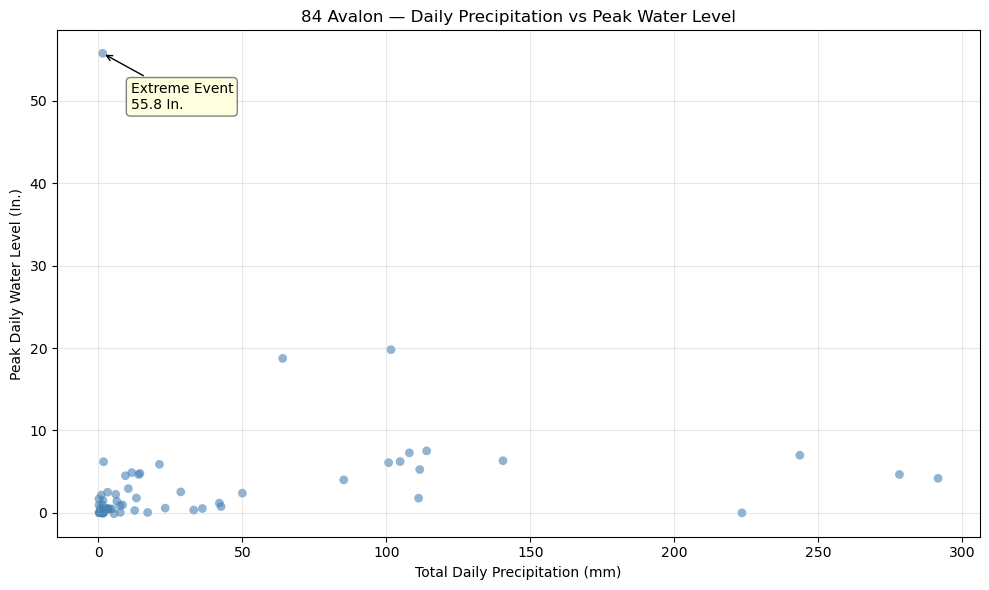

In [38]:
# Resample to daily — total rain vs peak water level per day
df_daily = df.resample('D', on='Time').agg(
    total_precip=('precipitation_mm_hourly', 'sum'),
    peak_water=('Value_float', 'max')
).reset_index()

# Only keep days where something happened
df_daily = df_daily[df_daily['total_precip'] > 0]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_daily['total_precip'], df_daily['peak_water'],
           alpha=0.6, color='steelblue', edgecolors='none', s=40)

# Annotate September outlier
peak_idx = df_daily['peak_water'].idxmax()
ax.annotate(
    f"Extreme Event\n{df_daily.loc[peak_idx, 'peak_water']:.1f} In.",
    xy=(df_daily.loc[peak_idx, 'total_precip'], df_daily.loc[peak_idx, 'peak_water']),
    xytext=(20, -40), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)

ax.set_xlabel('Total Daily Precipitation (mm)')
ax.set_ylabel('Peak Daily Water Level (In.)')
ax.set_title('84 Avalon — Daily Precipitation vs Peak Water Level')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()